# Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', 500)
pd.options.plotting.backend = "plotly"

# Data

In [2]:
filepath = os.path.join("..","data","processed","validations_fusion.csv")
df = pd.read_csv(filepath)

In [3]:
df.head()

,jour,libelle_arret,id_zdc,categorie_titre,nb_vald,jour_nom,mois_nom,nom_long,nom_so_gar,nom_su_gar,id_ref_zdc,nom_zdc,res_com,mode,train,rer,metro,tramway,val,tertrain,terrer,termetro,tertram,terval,exploitant,idf,principal,latitude,longitude
0,2025-03-07,MADELEINE,71324,Forfaits courts,3387,Friday,March,Madeleine,NaN,NaN,71324.0,Madeleine,METRO 8 / METRO 12 / METRO 14,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.870233,2.325164
1,2025-03-07,BARBES-ROCH.,71426,Autres titres,478,Friday,March,Barbès-Rochechouart,NaN,NaN,71426.0,Barbès Rochechouart,METRO 2 / METRO 4,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.883734,2.349525
2,2025-03-07,S. GAINSBOURG,490779,Contrat Solidarite Transport,781,Friday,March,Serge Gainsbourg,NaN,NaN,490779.0,Serge Gainsbourg,METRO 11,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.881316,2.427186
3,2025-03-07,S. GAINSBOURG,490779,Forfait Navigo,2880,Friday,March,Serge Gainsbourg,NaN,NaN,490779.0,Serge Gainsbourg,METRO 11,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.881316,2.427186
4,2025-03-07,S. GAINSBOURG,490779,Imagine R,1158,Friday,March,Serge Gainsbourg,NaN,NaN,490779.0,Serge Gainsbourg,METRO 11,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.881316,2.427186


In [4]:
df.shape

(1890468, 29)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1890468 entries, 0 to 1890467
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   jour             object 
 1   libelle_arret    object 
 2   id_zdc           int64  
 3   categorie_titre  object 
 4   nb_vald          int64  
 5   jour_nom         object 
 6   mois_nom         object 
 7   nom_long         object 
 8   nom_so_gar       object 
 9   nom_su_gar       object 
 10  id_ref_zdc       float64
 11  nom_zdc          object 
 12  res_com          object 
 13  mode             object 
 14  train            float64
 15  rer              float64
 16  metro            float64
 17  tramway          float64
 18  val              float64
 19  tertrain         float64
 20  terrer           float64
 21  termetro         float64
 22  tertram          float64
 23  terval           float64
 24  exploitant       object 
 25  idf              float64
 26  principal        float64
 27  latitude    

# Analyses.

## Validations par stations.

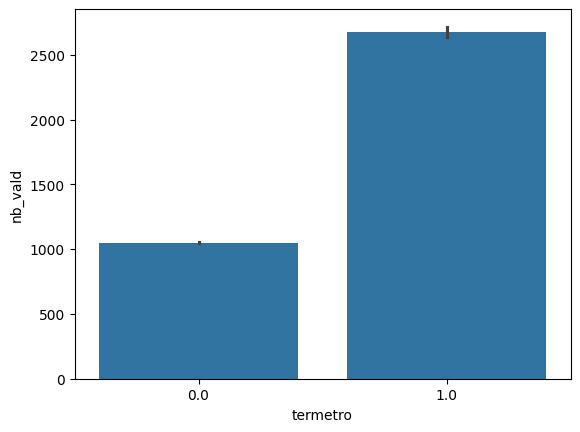

In [ ]:
# TEST: nombre ou somme ?

plt.figure()

sns.barplot(df, y="nb_vald", x="termetro")

plt.show()

In [17]:
#fig = px.scatter_map(
#    df,
#    lat="latitude",
#    lon="longitude",
#    hover_name= "nom_zdc",
#    hover_data="nb_vald"    
#)
#fig.update_layout(mapbox_style="open-street-map")
#fig.update_traces(marker_color='#64B5F6')
#fig

In [29]:
#fig = px.histogram(df, x="jour", y="nb_vald",)
#fig.update_traces(marker_color='#64B5F6')
#fig

In [6]:
top_stations_df = df.sort_values(by="nb_vald", ascending=False).head()

In [7]:
plt.figure()

sns.barplot(df, x="Ligne", y="somme_nb_vald", color="#64B5F6")

plt.show()

ValueError: Could not interpret value `Ligne` for `x`. An entry with this name does not appear in `data`.

<Figure size 640x480 with 0 Axes>

## Validations par lignes.

In [8]:
# Exemple filtrage des stations par lignes pour analyse.
df[df["res_com"].str.contains("RER B", na=False)].head()

,jour,libelle_arret,id_zdc,categorie_titre,nb_vald,jour_nom,mois_nom,nom_long,nom_so_gar,nom_su_gar,id_ref_zdc,nom_zdc,res_com,mode,train,rer,metro,tramway,val,tertrain,terrer,termetro,tertram,terval,exploitant,idf,principal,latitude,longitude
192,2025-03-07,SAINT-MICHEL,73620,Imagine R,4927,Friday,March,Saint-Michel,Notre-Dame,NaN,73620.0,Saint-Michel Notre-Dame,RER B / RER C / METRO 4,RER / METRO,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP/SNCF,1.0,0.0,48.853336,2.346035
261,2025-03-07,BOURGET T11,72641,Forfait Navigo,2488,Friday,March,Le Bourget,NaN,NaN,72641.0,Le Bourget,RER B / TRAM 11,RER / TRAM,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,SNCF,1.0,0.0,48.930740,2.425791
262,2025-03-07,BOURGET T11,72641,Forfaits courts,71,Friday,March,Le Bourget,NaN,NaN,72641.0,Le Bourget,RER B / TRAM 11,RER / TRAM,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,SNCF,1.0,0.0,48.930740,2.425791
347,2025-03-07,MASSY VERRIERES,63320,NON DEFINI,2,Friday,March,Massy-Verrières,NaN,NaN,63320.0,Massy - Verrières,RER B / RER C,RER,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP/SNCF,1.0,0.0,48.734888,2.274002
365,2025-03-07,SAINT-MICHEL NOTRE DAME,73620,Forfaits courts,4770,Friday,March,Saint-Michel,Notre-Dame,NaN,73620.0,Saint-Michel Notre-Dame,RER B / RER C / METRO 4,RER / METRO,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP/SNCF,1.0,0.0,48.853336,2.346035


In [9]:
# Somme "nb_vald" pour une ligne donnée.
df[df["res_com"].str.contains("RER B", na=False)]["nb_vald"].sum()

np.int64(190203361)

In [10]:
lignes_filepath = os.path.join("..","data","processed","validations_ligne.csv")
lignes_df = pd.read_csv(lignes_filepath)

In [11]:
lignes_df.head()

,Ligne,somme_nb_vald
0,RER A,324994656
1,RER B,190203361
2,RER C,180974086
3,RER D,191192832
4,RER E,201652557


In [28]:
#fig = px.histogram(lignes_df, x="Ligne", y="somme_nb_vald",)
#fig.update_traces(marker_color='#64B5F6')
#fig

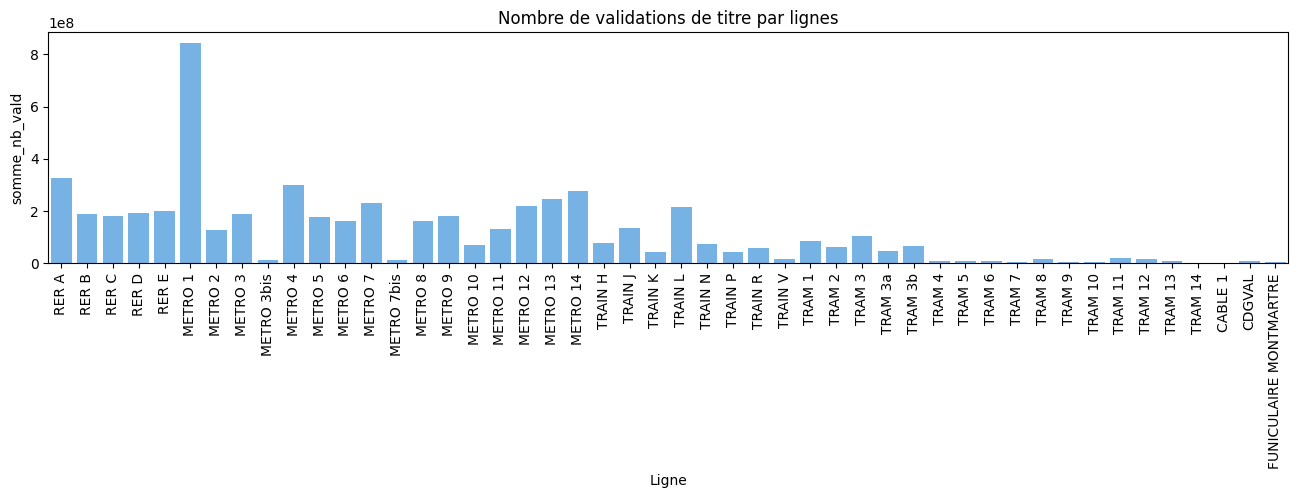

In [12]:
plt.figure(figsize=(16,3))

sns.barplot(lignes_df, x="Ligne", y="somme_nb_vald", color="#64B5F6")

plt.xticks(rotation="vertical")
plt.title("Nombre de validations de titre par lignes")

plt.show()

In [13]:
# Top lignes.
top_lignes_df = lignes_df.sort_values(by="somme_nb_vald", ascending=False).head()
top_lignes_df

,Ligne,somme_nb_vald
5,METRO 1,842868704
0,RER A,324994656
9,METRO 4,301538185
20,METRO 14,278501830
19,METRO 13,245353261


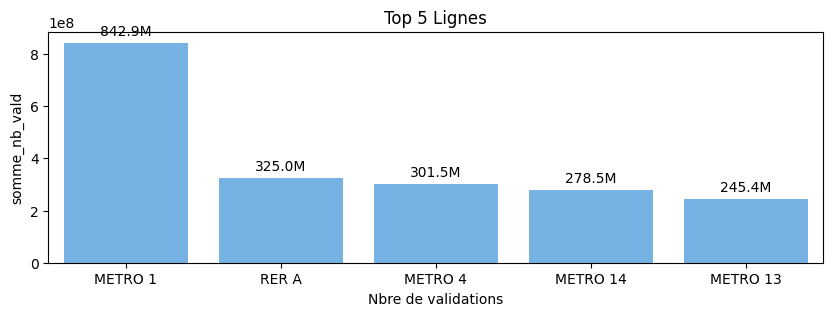

In [14]:
# Top lignes graphique.

plt.figure(figsize=(10,3))

ax = sns.barplot(top_lignes_df, x="Ligne", y="somme_nb_vald", color="#64B5F6")

ax.bar_label(
    ax.containers[0],
    fmt=lambda x: f"{x*1e-6:.1f}M",
    padding=3
)

plt.title("Top 5 Lignes")
plt.xlabel("Nbre de validations")

plt.show()

## Scatterplot